<a href="https://colab.research.google.com/github/27Kushal/PyTorch-learning/blob/main/pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. Computer Vision libraries in pytorch

* torchvision- base domain library for pytorch computer vision
* torchvision.datasets- get datasets and data loading functions for computer vision
* torchvision.models- get pretrained computer vision models that you can use for your problems
* torchvision.transforms- functions for manipulating your vision data(images) to be suitable to use with an ML model
* torch.utils.data.Dataset- Base dataset class for pytorch
* torch.utils.data.DataLoader- creates a python iterable over a dataset


In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


#1. Getting a dataset

using the fashion MNIST


##1.1 Downloading the data

In [2]:
#setup training data
train_data=datasets.FashionMNIST(
    root="data", #where to download data to
    train=True, #do we want the training data set?
    download=True,#do we want to download
    transform=ToTensor(), #how do we want to transform images
    target_transform=None #how do we want to transform labels
)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [3]:
len(train_data),len(test_data)

(60000, 10000)

In [4]:
image,label=train_data[0]
image,label
image.shape #(colour channel,height,width)

torch.Size([1, 28, 28])

In [5]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

##1.2 Visualizing the data

Image Shape:  torch.Size([1, 28, 28])


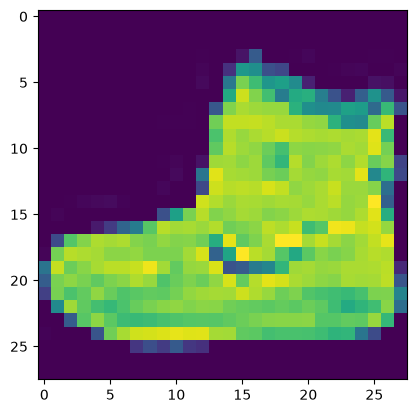

In [7]:
import matplotlib.pyplot as plt
image,label=train_data[0]
print("Image Shape: ",image.shape)
plt.imshow(image.squeeze())

Text(0.5, 1.0, 'Ankle boot')

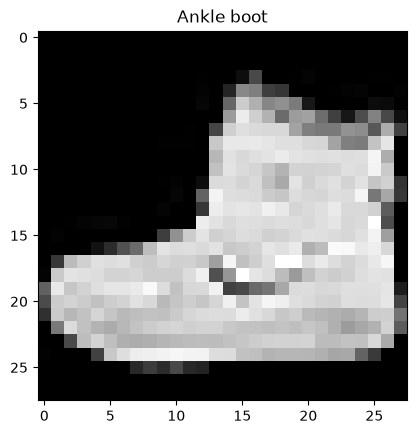

In [8]:
import matplotlib.pyplot as plt
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])

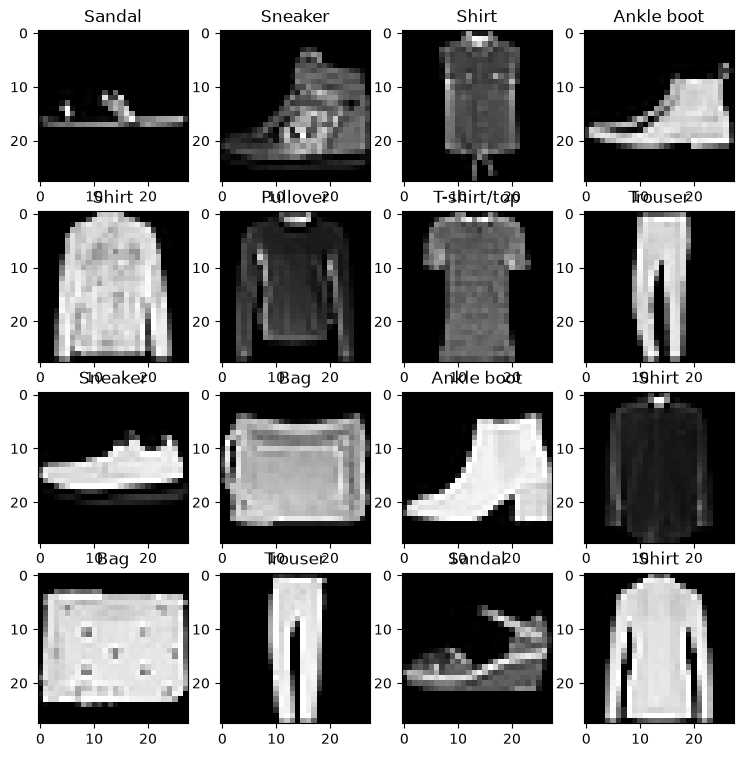

In [9]:
from numpy import random
fig=plt.figure(figsize=(9,9))
rows,columns=4,4
for i in range(1,rows*columns+1):
  random_idx=random.randint(0,len(train_data),size=[1]).item()
  image,label=train_data[random_idx]
  fig.add_subplot(rows,columns,i)
  plt.imshow(image.squeeze(),cmap="gray")
  plt.title(class_names[label])

#2. Prepare DataLoader

Right now our data is in form of pytorch datasets

DataLoader turns our data into python iterable

More specifically we want to turn our data into batches or mini batches.

Benefits-
* Computationally efficient as rather than training 60000 at once it trains one batch at a time
* it gives our neural network more chances to update gradients per epoch

In [10]:
from torch.utils.data import DataLoader
BATCH_SIZE=32

train_dataloader=DataLoader(dataset=train_data,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

test_dataloader=DataLoader(dataset=test_data,
                            batch_size=BATCH_SIZE,
                            shuffle=False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x79c805f5a630>,
 <torch.utils.data.dataloader.DataLoader at 0x79c806167fb0>)

In [11]:
print(f"Dataloaders: {train_dataloader,test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x79c805f5a630>, <torch.utils.data.dataloader.DataLoader object at 0x79c806167fb0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [12]:
#checking out what is inside the training dataloader
train_features_batch,train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 2,label size: torch.Size([])


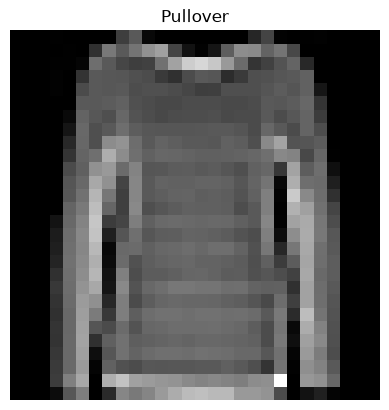

In [13]:
#show a sample
random_idx=torch.randint(0,len(train_features_batch),size=[1]).item()
img,label=train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis('off')
print(f"Image size: {img.shape}")
print(f"Label: {label},label size: {label.shape}")

#3. Model 0: Build a baseline model

It's best practice to start with a baseline model

A baseline model is a simple model you will try and improve upon with subsequent models/experiments.



In [14]:
#create a flatten layer
flatten_model=nn.Flatten()
#get a single sample
x=train_features_batch[0]
#flatten the sample
output=flatten_model(x)
print(output.shape) #[colour channels,height*width]
print(x.shape) #[colour channels,height,width]

torch.Size([1, 784])
torch.Size([1, 28, 28])


In [15]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_shape)
    )

  def forward(self,x):
    return self.layer_stack(x)

In [16]:
torch.manual_seed(42)
#baseline model
model_0=FashionMNISTModelV0(input_shape=784, #this is 28*28
                            hidden_units=10,
                            output_shape=len(class_names) #one for every class
                            )

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

##3.1 Setup loss,optimizerand evaluation metrics

* Loss function- since we are working with multi-class data, our loss function will be nn.CrossEntropyLoss()
* Optimizer-stochastic gradient descent
* Evaluation metric- since we're working on a classification problem, using accuracy as metric


In [17]:
#calculate accuracy(classification metric)
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item() #torch.eq() calculates where 2 tensors are equal
  acc=(correct/len(y_pred))*100
  return acc

# we could have imported the accuracy function from the helper_functions.py in github

In [18]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

##3.2 creating a function to time our experiments

Machine learning is very experimental

2 of the main things we need often want to track are:
* Model's performance(loss and accuracy values etc)
* how fast it runs

In [19]:
from timeit import default_timer as Timer

def print_train_time(start:float,end:float,device:torch.device=None):
  """Prints difference between start and end time"""
  total_time=end-start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [20]:
start_time=Timer()
#some code...
end_time=Timer()
print_train_time(start=start_time,end=end_time,device=None)

Train time on None: 0.000 seconds


3.5102999959235603e-05

##3.3 Creating a training loop and training a model on batches of data

1. Loop through epochs
2. Loop through training batches, perform training steps, calculate the train loss **per batch**
3. Loop through testing batches, perform testing steps, calculate the test loss per batch
4. Print out what is happening
5. Time it out

In [21]:
#import tqdm for progress bar
from tqdm.auto import tqdm

#set the seed and start the timer
torch.manual_seed(42)
train_time_start=Timer()

epochs=3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  ###training
  train_loss=0
  #add a loop to loop through the training batches
  for batch,(x,y) in enumerate(train_dataloader):
    model_0.train()
    #forward pass
    y_pred=model_0(x)
    #calculate the loss(per batch)
    loss=loss_fn(y_pred,y)
    train_loss+=loss #accumulate train loss
    #optimizer zero grad
    optimizer.zero_grad()
    #loss backward
    loss.backward()
    #optimizer step
    optimizer.step()
    #print out what is happening
    if batch%400==0:
      print(f"Looked at {batch*len(x)}/{len(train_dataloader.dataset)} samples")

  #divide total train loss by length of train dataloader
  train_loss/=len(train_dataloader)

  #testing
  test_loss,test_acc=0,0
  model_0.eval()
  with torch.inference_mode():
    for x_test,y_test in test_dataloader:
      test_pred=model_0(x_test)
      test_loss+=loss_fn(test_pred,y_test)
      test_acc+=accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))
    test_loss/=len(test_dataloader)
    test_acc/=len(test_dataloader)
  print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.5f}")
  #calulate training time
  train_time_end=Timer()
  total_train_time_model_0=print_train_time(start=train_time_start,end=train_time_end,device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.59039 | Test loss: 0.50954 | Test acc: 82.03874
Train time on cpu: 11.514 seconds
Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.47633 | Test loss: 0.47989 | Test acc: 83.19688
Train time on cpu: 23.013 seconds
Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.45503 | Test loss: 0.47664 | Test acc: 83.42652
Train time on cpu: 35.863 seconds


#4. Make predictions and get Model 0 results

In [22]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn):
  """Returns a dictionary containing the results of model predicting on dataloader"""
  loss,acc=0,0
  model.eval()
  with torch.inference_mode():
    for x,y in dataloader:
      #make predictions
      y_pred=model(x)
      #accumulate the loss and acc values per batch
      loss+=loss_fn(y_pred,y)
      acc+=accuracy_fn(y_true=y,
                       y_pred=y_pred.argmax(dim=1))
    #scale loss and acc to find the average loss/acc per batch
    loss/=len(dataloader)
    acc/=len(dataloader)
  #returns dictionary
  return {"model_name": model.__class__.__name__, #only works when model created with a class
          "model_loss": loss.item(),
          "model_acc":acc}

#calculate model 0 results on test dataset
model_0_results=eval_model(model=model_0,
                           dataloader=test_dataloader,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

#5. Setup device agnostic code(for using GPU)

In [23]:
#setup device agnostic code
import torch
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

#6. Model 1: Building a better model with non-linearity


In [24]:
#let's create a model with linear and non linear layers
class FashionMNISTV1(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(), #flatten inputs into a single vector
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_shape),
        nn.ReLU()
    )
  def forward(self,x:torch.Tensor):
    return self.layer_stack(x)

In [25]:
torch.manual_seed(42)
model_1=FashionMNISTV1(input_shape=784, #this is the output of the flatten layer
                       hidden_units=10,
                       output_shape=len(class_names)).to(device)
next(model_1.parameters()).device

device(type='cpu')

##6.1 Setup loss, optimizer and evaluation metrics

In [26]:
# from helper_functions import accuracy_fn
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.1)

##6.2 Functionizing training and evaluation/testing loops

let's create function for:
* training loop- train_step()
* testing loop-test_step()

In [27]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device=device):
  """Performs a training with model trying to learn on data loader"""
  train_loss,train_acc=0,0
  model.to(device)
  #put model on training mode
  model.train()

  #add a loop to loop through the training batches
  for batch,(x,y) in enumerate(data_loader):

    #put data on target device
    x,y=x.to(device),y.to(device)

    #forward pass(outputs the raw logits from the model)
    y_pred=model(x)

    #calculate loss
    loss=loss_fn(y_pred,y)
    train_loss+=loss #accumulate the train loss
    train_acc+=accuracy_fn(y_true=y,
                           y_pred=y_pred.argmax(dim=1))#go from logits->prediction labels

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss/=len(data_loader)
  train_acc/=len(data_loader)

  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}")

In [28]:
def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device:torch.device=device):
  """Performs a testing loop step on model going over data loader"""

  test_loss,test_acc=0,0
  model.to(device)
  #put model in eval mode
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      x,y=x.to(device),y.to(device)
      test_pred=model(x)
      test_loss+=loss_fn(test_pred,y)
      test_acc+=accuracy_fn(y_true=y,y_pred=test_pred.argmax(dim=1))

    test_loss/=len(data_loader)
    test_acc/=len(data_loader)

    print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}")

In [29]:
torch.manual_seed(42)

#measure time
from timeit import default_timer as timer

train_time_start=timer()

epochs=3

#create a optimization and evaluation loop using train_step() and test_step()
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end=timer()
total_train_time_model_1=print_train_time(start=train_time_start,end=train_time_end,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 1.09199 | Train acc: 61.34
Test loss: 0.95636 | Test acc: 65.00
Epoch: 1
-------
Train loss: 0.78101 | Train acc: 71.93
Test loss: 0.72227 | Test acc: 73.91
Epoch: 2
-------
Train loss: 0.67027 | Train acc: 75.94
Test loss: 0.68500 | Test acc: 75.02
Train time on cpu: 41.549 seconds


**Note:** Sometimes,depending on your data/hardware you might find that the model trains faster on CPU than GPU

Why is that?
* It could be overhead for copying data/model to and from gpu outweighs the compute benefits of the gpu
* the hardware you are using have better CPU in terms of compute capabilities than GPU.


In [30]:
#eval_model is not device agnostic so recreating it with device agnostic code

def eval_model(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               device:torch.device=device):
  """Returns a dictionary containing the results of model predicting on dataloader"""
  loss,acc=0,0
  model.eval()
  with torch.inference_mode():
    for x,y in tqdm(dataloader): #adding tqdm over the data in for loop creates progress bar
      #moving it to the device
      x,y=x.to(device),y.to(device)
      #make predictions
      y_pred=model(x)
      #accumulate the loss and acc values per batch
      loss+=loss_fn(y_pred,y)
      acc+=accuracy_fn(y_true=y,
                       y_pred=y_pred.argmax(dim=1))
    #scale loss and acc to find the average loss/acc per batch
    loss/=len(dataloader)
    acc/=len(dataloader)
  #returns dictionary
  return {"model_name": model.__class__.__name__, #only works when model created with a class
          "model_loss": loss.item(),
          "model_acc":acc}


In [31]:
model_1_results=eval_model(model=model_1,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn,
                           dataloader=test_dataloader,
                           device=device)

model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTV1',
 'model_loss': 0.6850009560585022,
 'model_acc': 75.01996805111821}

# 7. Model 2: Building a Convulutional Neural Network

CNN's are also called as CovNets

CNN's are known for there capabilities in learning patterns in visual data

In [32]:
#create a convolutional neural network
class FashionMNISTV2(nn.Module):
  """Model architecture that replicates the TinyVGG
  model from cnn explainer website."""
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.conv_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, #this requires calculation(we wrote this multiplication by seeing the error in matrix multiplication)
                  out_features=output_shape)
    )
  def forward(self,x:torch.Tensor):
    x=self.conv_block_1(x)
    # print(x.shape)
    x=self.conv_block_2(x)
    # print(x.shape)
    x=self.classifier(x)
    return x

In [33]:
torch.manual_seed(42)
model_2=FashionMNISTV2(input_shape=1,#as we have only 1 colour(black)
                       hidden_units=10,
                       output_shape=len(class_names)).to(device)

In [34]:
rand_image_tensor=torch.randn(size=(1,28,28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [35]:
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], grad_fn=<AddmmBackward0>)

##7.1 Stepping through nn.Conv2d

In [36]:
torch.manual_seed(42)

#create a batch of images
images=torch.randn(size=(32,3,64,64))
test_image=images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape:{test_image.shape}")
print(f"Test image:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape:torch.Size([3, 64, 64])
Test image:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7

In [37]:
#create a single conv2d layer
conv_layer=nn.Conv2d(in_channels=3,
                     out_channels=10,
                     kernel_size=(3,3),
                     stride=1,
                     padding=0)

#pass the data through the convolutional layer
conv_output=conv_layer(test_image.unsqueeze(0))
conv_output.shape

torch.Size([1, 10, 62, 62])

##7.2 Stepping through nn.MaxPool2d

In [38]:
test_image

tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7978,  1.0261,  1.1465,  ...,  1.2134,  0.9354, -0.0780],
         [-1.4647, -1.9571,  0.1017,  ..., -1

In [39]:
#printout original image shape without unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(0).shape}")

max_pool_layer=nn.MaxPool2d(kernel_size=2)

#pass data through just conv layer
test_image_conv_output=conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_conv_output.shape}")

#pass data through the max pool layer
test_image_output=max_pool_layer(test_image_conv_output)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_output.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


##7.3 Setup the loss function and optimizer for model 2

In [40]:
#setup loss function/eval metrics/optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_2.parameters(),
                          lr=0.1)

##7.4 Training and testing model_2 using our training and test functions

In [41]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
train_time_start_model_2=timer()

epochs=3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_model_2=timer()
total_train_time_model_2=print_train_time(start=train_time_start_model_2,end=train_time_end_model_2,device=device)



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.59518 | Train acc: 78.38
Test loss: 0.39500 | Test acc: 85.99
Epoch: 1
-------
Train loss: 0.36536 | Train acc: 86.90
Test loss: 0.35244 | Test acc: 86.91
Epoch: 2
-------
Train loss: 0.32588 | Train acc: 88.13
Test loss: 0.32719 | Test acc: 88.07
Train time on cpu: 199.555 seconds


In [42]:
model_2_results=eval_model(model=model_2,
                           dataloader=test_dataloader,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn,
                           device=device)

model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

#8. Compare model results and training time

In [43]:
import pandas as pd
compare_results=pd.DataFrame([model_0_results,model_1_results,model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTV1,0.685001,75.019968
2,FashionMNISTV2,0.327190,88.069089


In [44]:
#add training time to results comparison
compare_results["training_time"]=[total_train_time_model_0,
                                  total_train_time_model_1,
                                  total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,35.863328
1,FashionMNISTV1,0.685001,75.019968,41.549174
2,FashionMNISTV2,0.327190,88.069089,199.555135


Text(0, 0.5, 'model')

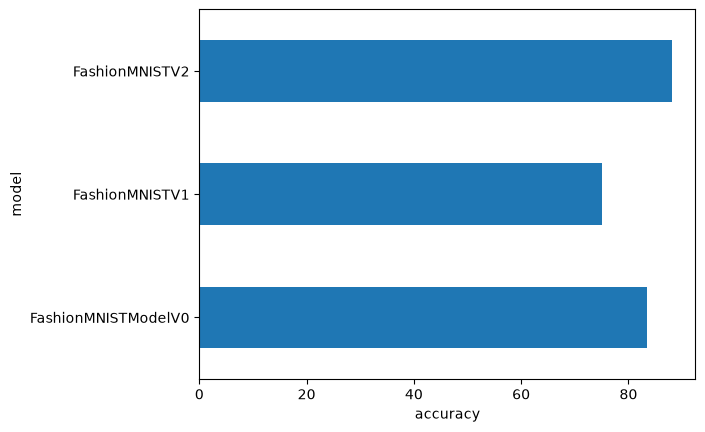

In [45]:
#visualize our results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy")
plt.ylabel("model")

#9. Make and evaluate random predictions with best model



In [46]:
def make_predictions(model:torch.nn.Module,
                     data:list,
                     device:torch.device=device):
  pred_probs=[]
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      #prepare the sample(add a batch dimension)
      sample=torch.unsqueeze(sample,dim=0).to(device)
      #forward pass(model outputs raw logits)
      pred_logit=model(sample)
      #get prediction probability
      pred_prob=torch.softmax(pred_logit.squeeze(),dim=0)
      #get pred_prob off the gpu for further calculations
      pred_probs.append(pred_prob.cpu())

  #stack the pred_probs to turn list to tensor
  return torch.stack(pred_probs)

In [47]:
import random
# random.seed(42)
test_samples=[]
test_labels=[]

for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'T-shirt/top')

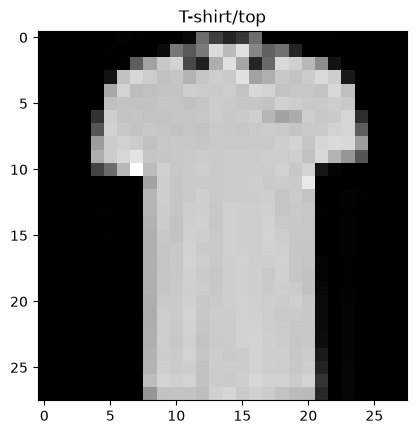

In [48]:
plt.imshow(test_samples[0].squeeze(),cmap="gray")
plt.title(class_names[test_labels[0]])

In [49]:
#make predictions
pred_probs=make_predictions(model=model_2,
                            data=test_samples)
pred_probs[:2]

tensor([[9.7761e-01, 3.4838e-06, 4.3524e-04, 1.3065e-03, 2.3674e-04, 6.8620e-08,
         2.0337e-02, 5.9460e-07, 7.1991e-05, 2.9832e-07],
        [8.6811e-01, 2.6732e-06, 8.3592e-05, 3.6999e-03, 3.6380e-04, 1.4045e-07,
         1.2768e-01, 1.5775e-06, 5.5461e-05, 5.6043e-07]])

In [50]:
#convert prediction probabilities to labels
pred_classes=pred_probs.argmax(dim=1)
pred_classes

tensor([0, 0, 6, 9, 2, 3, 9, 4, 4])

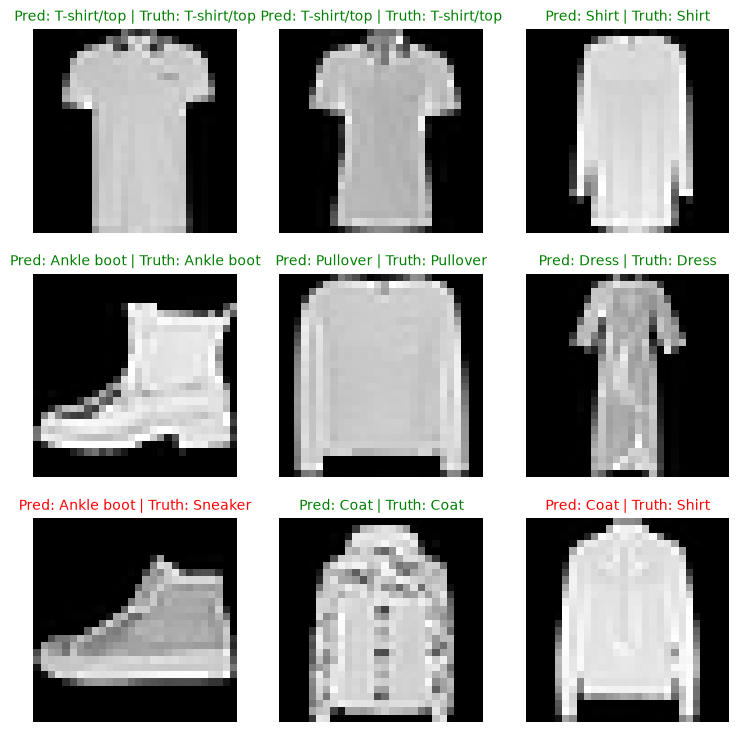

In [51]:
#plot predictions
plt.figure(figsize=(9,9))
nrows=3
ncols=3
for i,sample in enumerate(test_samples):
  #create subplots
  plt.subplot(nrows,ncols,i+1)
  #plot the target image
  plt.imshow(sample.squeeze(),cmap="gray")
  #find the prediction(in text form,eg-"sandal")
  pred_label=class_names[pred_classes[i]]
  #get the truth label in text form
  truth_label=class_names[test_labels[i]]
  #create a title for the plot
  title_text=f"Pred: {pred_label} | Truth: {truth_label}"
  #check for equality between pred and truth and change colour of the title text
  if pred_label==truth_label:
    plt.title(title_text,fontsize=10,color="green")
  else:
    plt.title(title_text,fontsize=10,color="red")

  plt.axis(False);

#10. Making a confusion matrix for further prediction evaluation

a confusion matrix is a fantastic way of evaluating your model visually.

1. Make predictions with our trained model on the test dataset
2. Make confusion matrix "torchmetrics.ConfusionMatrix"
3. Plot the confusion matrix using "mlxtend.plotting.plot_confusion_matrix()"


In [52]:
#import tqdm.auto
from tqdm.auto import tqdm

#1. Make predictions with trained model
y_preds=[]
model_2.eval()
with torch.inference_mode():
  for x,y in tqdm(test_dataloader,desc="Making predictions"):
    #send data and targets to target device
    x,y=x.to(device),y.to(device)
    #do the forward pass
    y_logit=model_2(x)
    #turn predictions from logits-> prediction probs
    y_pred=torch.softmax(y_logit.squeeze(),dim=0).argmax(dim=1)
    #put predictions on cpu for evaluation
    y_preds.append(y_pred.cpu())

#concatenate list of predictions into a tensor
# print(y_preds)
y_pred_tensor=torch.cat(y_preds)
y_pred_tensor[:10]

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

since due to version error we were not able to download and import torchmertics so installing it then restarting runtime then importing it so it works properly

In [55]:
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19.0 or higher"
except:
    !pip install torchmetrics -U mlxtend -q
    import os
    os.kill(os.getpid(), 9)  # force restart runtime

mlxtend version: 0.25.0


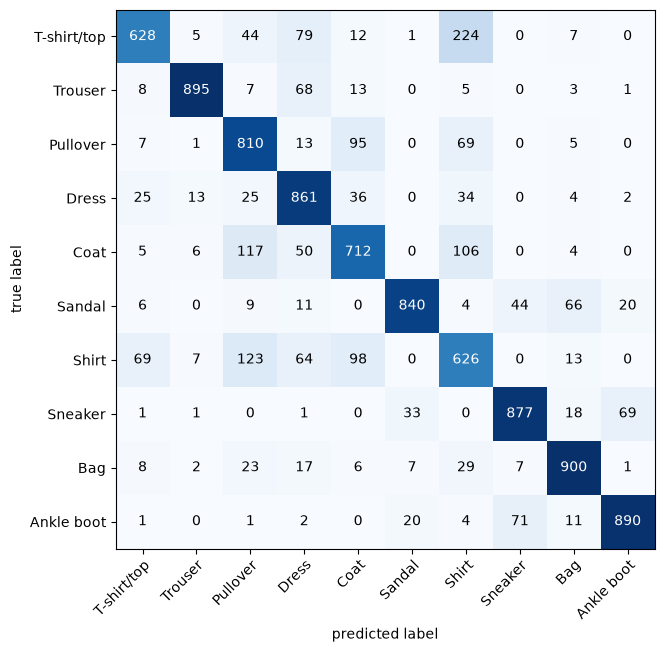

In [56]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

#Setup confusion instance and compare predictions to targets
confmat=ConfusionMatrix(num_classes=len(class_names),task="multiclass")
confmat_tensor=confmat(preds=y_pred_tensor,
                       target=test_data.targets)
#plot the confusion matrix
fig,ax=plot_confusion_matrix(conf_mat=confmat_tensor.numpy(), #matplotlib likes working with numpy
                             class_names=class_names,
                             figsize=(10,7))

#11. Save and load best performing model


In [58]:
from pathlib import Path

MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

#create model save
MODEL_NAME="03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME

#save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_2.pth


In [61]:
#create a new instance
torch.manual_seed(42)

loaded_model_2=FashionMNISTV2(input_shape=1,
                                   hidden_units=10,
                                   output_shape=len(class_names))
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

#send model to target device
loaded_model_2.to(device)
loaded_model_2

FashionMNISTV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)